## 1. ConvNeXt-Tiny Galaxy Morphology Classification

This notebook trains an ImageNet-pretrained ConvNeXt-Tiny model to classify galaxy images into **elliptical, spiral, and irregular** classes. Galaxy Zoo 2 metadata is used to create high-confidence labels and balanced train/validation/test splits. The model is fully fine-tuned in two stages: AdamW training followed by lower-learning-rate SGD polishing. The best model is selected based on validation accuracy and evaluated on a held-out test set.

In [1]:
import os
import json
import random
import shutil
import time

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")

print("TensorFlow version:", tf.__version__)
print("GPU devices:", gpus)

if gpus:
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision is enabled.")
else:
    mixed_precision.set_global_policy("float32")
    print("GPU not found. Select Kaggle Settings -> Accelerator -> GPU.")


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision is enabled.


## 2. Environment and Reproducibility Setup

This section imports the required libraries and prepares the training environment. A fixed random seed improves reproducibility, while GPU availability is checked and mixed precision is enabled when supported for more efficient training.


In [2]:
DATASET_ROOT = Path(
    "/kaggle/input/datasets/uzeyirisrafil/galaxy-zoo-2"
)
WORK_ROOT = Path("/kaggle/working")

MAPPING_PATH = DATASET_ROOT / "gz2_filename_mapping.csv"

hart_candidates = [
    DATASET_ROOT / "gz2_hart16.csv",
    DATASET_ROOT / "gz2_hart16.csv.gz",
]
HART_PATH = next((p for p in hart_candidates if p.exists()), None)

IMAGE_ROOT = DATASET_ROOT / "images_gz2"
IMAGE_FOLDER = (
    IMAGE_ROOT / "images"
    if (IMAGE_ROOT / "images").is_dir()
    else IMAGE_ROOT
)

THREE_CLASS_DIR = WORK_ROOT / "galaxy_3class"
SPLIT_DIR = WORK_ROOT / "galaxy_split"
SAVE_DIR = WORK_ROOT / "saved_models"
RESULTS_DIR = WORK_ROOT / "results"

SAVE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not MAPPING_PATH.is_file():
    raise FileNotFoundError(f"Mapping file not found: {MAPPING_PATH}")
if HART_PATH is None:
    raise FileNotFoundError("gz2_hart16.csv or .csv.gz was not found.")
if not IMAGE_FOLDER.is_dir():
    raise FileNotFoundError(f"Image folder not found: {IMAGE_FOLDER}")

image_count = sum(1 for _ in IMAGE_FOLDER.glob("*.jpg"))
if image_count == 0:
    raise FileNotFoundError(f"No JPG files found: {IMAGE_FOLDER}")

print("Mapping path:", MAPPING_PATH)
print("Hart path:", HART_PATH)
print("Image folder:", IMAGE_FOLDER)
print("JPG count:", image_count)
print("Results directory:", RESULTS_DIR)


Mapping path: /kaggle/input/datasets/uzeyirisrafil/galaxy-zoo-2/gz2_filename_mapping.csv
Hart path: /kaggle/input/datasets/uzeyirisrafil/galaxy-zoo-2/gz2_hart16.csv
Image folder: /kaggle/input/datasets/uzeyirisrafil/galaxy-zoo-2/images_gz2/images
JPG count: 243434
Results directory: /kaggle/working/results


## 3. Project Paths and Dataset Files
Defines the main dataset, working, split, model, and results paths used in the notebook.

In [3]:
mapping = pd.read_csv(MAPPING_PATH)
hart = pd.read_csv(HART_PATH)

print("Mapping shape:", mapping.shape)
print("Hart shape:", hart.shape)

display(mapping.head())
display(hart.head())

print("Mapping columns:")
print(mapping.columns.tolist())

print("\nHart columns:")
print(hart.columns.tolist())

Mapping shape: (355990, 3)
Hart shape: (239695, 231)


,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


Mapping columns:
['objid', 'sample', 'asset_id']

Hart columns:
['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_we

## 4. Loading Galaxy Zoo 2 Metadata

The notebook loads the Galaxy Zoo 2 mapping file together with the Hart16 metadata used for the morphology labels. Before any label construction, the code prints the table shapes, sample rows, and available columns. This provides a quick check that the expected files were loaded correctly and that the metadata contains the fields needed for the later filtering and merging steps.


In [4]:
mapping["objid"] = pd.to_numeric(mapping["objid"], errors="coerce").astype("Int64")
hart["dr7objid"] = pd.to_numeric(hart["dr7objid"], errors="coerce").astype("Int64")

merged = mapping.merge(
    hart,
    left_on="objid",
    right_on="dr7objid",
    how="inner",
    validate="many_to_one",
)

df = merged.copy()
df["asset_id"] = pd.to_numeric(df["asset_id"], errors="coerce")
df = df.dropna(subset=["asset_id"]).copy()
df["asset_id"] = df["asset_id"].astype("int64")

print("Merged shape:", df.shape)
display(df[["objid", "asset_id", "gz2_class"]].head(10))


Merged shape: (239695, 234)


,objid,asset_id,gz2_class
0,587722981741363294,3,Sb
1,587722981741363323,4,Sc?l
2,587722981741559888,5,Er
3,587722981741625481,6,Sc1t
4,587722981741625484,7,Sb
5,587722981741625520,8,Ei
6,587722981741625545,9,Er
7,587722981741756545,11,Sb
8,587722981741756579,12,SBc
9,587722981741822057,13,Ec


## 5. Merging Metadata and Image IDs
Merges the metadata using the galaxy object ID and keeps the image asset ID needed to find the corresponding JPG file.

In [ ]:
THRESHOLD = 0.80

required_columns = [
    "t01_smooth_or_features_a01_smooth_weighted_fraction",
    "t01_smooth_or_features_a02_features_or_disk_weighted_fraction",
    "t04_spiral_a08_spiral_weighted_fraction",
    "t08_odd_feature_a22_irregular_weighted_fraction",
]
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise KeyError(f"Required columns are missing from the Hart CSV: {missing_columns}")

elliptical_mask = (
    df["t01_smooth_or_features_a01_smooth_weighted_fraction"] >= THRESHOLD
)

spiral_mask = (
    (df["t01_smooth_or_features_a02_features_or_disk_weighted_fraction"] >= THRESHOLD)
    & (df["t04_spiral_a08_spiral_weighted_fraction"] >= THRESHOLD)
)

irregular_mask = (
    df["t08_odd_feature_a22_irregular_weighted_fraction"] >= THRESHOLD
)

candidate_count = (
    elliptical_mask.astype("int8")
    + spiral_mask.astype("int8")
    + irregular_mask.astype("int8")
)

df["label"] = pd.NA
df.loc[elliptical_mask & (candidate_count == 1), "label"] = "elliptical"
df.loc[spiral_mask & (candidate_count == 1), "label"] = "spiral"
df.loc[irregular_mask & (candidate_count == 1), "label"] = "irregular"

print("Overlapping high-confidence rows removed:", int((candidate_count > 1).sum()))

df = df.dropna(subset=["label"]).copy()
print(df["label"].value_counts())


Overlapping high-confidence rows removed: 4486
label
elliptical    103196
spiral         22780
irregular       3296
Name: count, dtype: int64


## 6. Creating High-Confidence Galaxy Labels

Galaxy Zoo 2 vote fractions are used to assign the three target classes with a **0.80 threshold**. Each galaxy is assigned to at most one class, reducing ambiguous samples and label noise. The resulting labels are then used to build the balanced image dataset.


In [6]:
available_image_ids = {p.stem for p in IMAGE_FOLDER.glob("*.jpg")}

df_with_images = df[
    df["asset_id"].astype(str).isin(available_image_ids)
].copy()

available_counts = df_with_images["label"].value_counts()
missing_classes = {"elliptical", "spiral", "irregular"} - set(available_counts.index)
if missing_classes:
    raise ValueError(f"Classes with no available image samples: {missing_classes}")

N_PER_CLASS = int(available_counts.min())
if N_PER_CLASS < 1000:
    print("WARNING: the smallest class has fewer than 1000 images; reaching 80% may be harder.")

balanced_df = pd.concat(
    [
        group.sample(n=N_PER_CLASS, random_state=SEED)
        for _, group in df_with_images.groupby("label", sort=True)
    ],
    ignore_index=True,
)

balanced_df = balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Available before balancing:")
print(available_counts)
print()
print("Balanced:")
print(balanced_df["label"].value_counts())
print()
print("Total images:", len(balanced_df))


Available before balancing:
label
elliptical    103173
spiral         22779
irregular       3295
Name: count, dtype: int64

Balanced:
label
irregular     3295
elliptical    3295
spiral        3295
Name: count, dtype: int64

Total images: 9885


## 7. Checking Image Availability and Balancing Classes

The notebook verifies that each labeled sample has a corresponding JPG image and removes missing samples. The remaining data are balanced by matching all three classes to the size of the smallest class, preventing class imbalance and model bias.


In [ ]:
assert IMAGE_FOLDER.is_dir()
print("Images will be read directly from Kaggle Input:", IMAGE_FOLDER)

Images will be read directly from Kaggle Input: /kaggle/input/datasets/uzeyirisrafil/galaxy-zoo-2/images_gz2/images


## 8. Preparing the Three-Class Image Dataset
Organizes the selected images into separate folders for the three morphology classes and checks that the files were copied correctly.

In [8]:
classes = ["elliptical", "spiral", "irregular"]

if THREE_CLASS_DIR.exists():
    shutil.rmtree(THREE_CLASS_DIR)

for cls in classes:
    (THREE_CLASS_DIR / cls).mkdir(parents=True, exist_ok=True)

copied = 0
missing = 0

for row in balanced_df.itertuples(index=False):
    asset_id = int(row.asset_id)
    label = row.label
    src = IMAGE_FOLDER / f"{asset_id}.jpg"
    dst = THREE_CLASS_DIR / label / f"{asset_id}.jpg"

    if src.is_file():
        shutil.copy2(src, dst)
        copied += 1
    else:
        missing += 1

print("Copied:", copied)
print("Missing:", missing)

if missing:
    raise RuntimeError("An unexpected missing image was detected after balancing.")


Copied: 9885
Missing: 0


In [ ]:
for cls in classes:
    count = sum(1 for _ in (THREE_CLASS_DIR / cls).glob("*.jpg"))
    print(f"{cls}: {count}")

elliptical: 3295
spiral: 3295
irregular: 3295


## 9. Creating Train, Validation, and Test Splits
Splits the balanced dataset into **68% training, 12% validation, and 20% testing**. The test set remains separate for final evaluation.

In [ ]:
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "validation", "test"]:
    for cls in classes:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

for cls in classes:
    files = sorted((THREE_CLASS_DIR / cls).glob("*.jpg"))
    rng = random.Random(SEED)
    rng.shuffle(files)

    n_total = len(files)
    n_test = int(round(n_total * 0.20))
    n_validation = int(round(n_total * 0.12))

    test_files = files[:n_test]
    validation_files = files[n_test:n_test + n_validation]
    train_files = files[n_test + n_validation:]

    for split, split_files in [
        ("train", train_files),
        ("validation", validation_files),
        ("test", test_files),
    ]:
        for src in split_files:
            shutil.copy2(src, SPLIT_DIR / split / cls / src.name)

print("Fresh 68% train / 12% validation / 20% test split created.")


Fresh 68% train / 12% validation / 20% test split created.


## 10. Checking Split Sizes
Checks the number of images in each class and split as a dataset sanity check.

In [11]:
for split in ["train", "validation", "test"]:
    print()
    print(split.upper())
    total = 0
    for cls in classes:
        count = sum(1 for _ in (SPLIT_DIR / split / cls).glob("*.jpg"))
        total += count
        print(f"{cls}: {count}")
    print("Total:", total)



TRAIN
elliptical: 2241
spiral: 2241
irregular: 2241
Total: 6723

VALIDATION
elliptical: 395
spiral: 395
irregular: 395
Total: 1185

TEST
elliptical: 659
spiral: 659
irregular: 659
Total: 1977


## 11. Building TensorFlow Input Pipelines
Loads the train, validation, and test folders as TensorFlow datasets with **256×256** images and a batch size of **16**.

In [12]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

train_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=True,
    seed=SEED,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_names=classes,
    label_mode="int",
    shuffle=False,
)

test_file_paths = list(test_dataset.file_paths)


Found 6723 files belonging to 3 classes.


I0000 00:00:1788443956.304228      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788443956.310367      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1185 files belonging to 3 classes.
Found 1977 files belonging to 3 classes.


## 12. Dataset Prefetching and Augmentation Choice
Uses TensorFlow prefetching to improve input efficiency. Training augmentation is disabled for this experiment because it did not improve the observed ConvNeXt performance.

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)


In [ ]:
print("Training augmentation: OFF")

Training augmentation: OFF


## 13. Loading ConvNeXt-Tiny and Building the Classifier

An **ImageNet-pretrained ConvNeXt-Tiny** backbone is used without its original classification head. A new classifier for the three galaxy morphology classes is added, while the full backbone remains trainable for fine-tuning. ConvNeXt's built-in preprocessing is kept enabled, so no additional `/255` rescaling is applied.


In [ ]:
from tensorflow.keras.applications import ConvNeXtTiny

base_model = ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    include_preprocessing=True,
    pooling="avg",
)

base_model.trainable = True

print("ConvNeXt-Tiny loaded; full backbone is trainable.")

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ConvNeXt-Tiny loaded; full backbone is trainable.


## 14. Stage 1 — AdamW Training Setup

Stage 1 performs full fine-tuning using **AdamW** with a learning rate and weight decay of `1e-4`. Validation accuracy is monitored to save the best checkpoint, while early stopping and learning-rate reduction help prevent overfitting and improve training stability.


In [ ]:
inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")

x = base_model(inputs)

outputs = layers.Dense(
    len(classes),
    activation="softmax",
    dtype="float32",
    name="classifier",
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="GalaxyZoo_ConvNeXtTiny_FullFineTune",
)

model.summary()

Model: "GalaxyZoo_ConvNeXtTiny_FullFineTune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 768)            │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │         2,307 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,822,435 (106.13 MB)

 Trainable params: 27,822,435 (106.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4,
        global_clipnorm=1.0,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## 15. Stage 1 — Full ConvNeXt-Tiny Training

The full ConvNeXt-Tiny model is trained for up to **30 epochs**. The best checkpoint is selected based on validation accuracy rather than the final epoch, and its performance is stored for comparison with Stage 2.


In [ ]:
STAGE1_PATH = str(RESULTS_DIR / "convnext_tiny_adamw_best.keras")

stage1_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    STAGE1_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

stage1_earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1,
)

stage1_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1,
)

stage1_csv = tf.keras.callbacks.CSVLogger(
    str(RESULTS_DIR / "convnext_stage1_log.csv")
)

In [ ]:
start_time = time.time()

history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[
        stage1_checkpoint,
        stage1_earlystop,
        stage1_reduce_lr,
        stage1_csv,
    ],
)

stage1_time = time.time() - start_time
print(f"Stage 1 training time: {stage1_time / 60:.1f} minutes")

Epoch 1/30


2026-09-03 14:00:33.809297: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-03 14:00:33.953953: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788444056.794553     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


420/421 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7655 - loss: 0.5630

2026-09-03 14:04:03.955210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-03 14:04:04.089961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.7656 - loss: 0.5627
Epoch 1: val_accuracy improved from None to 0.85485, saving model to /kaggle/working/results/convnext_tiny_adamw_best.keras

Epoch 1: finished saving model to /kaggle/working/results/convnext_tiny_adamw_best.keras
421/421 ━━━━━━━━━━━━━━━━━━━━ 396s 527ms/step - accuracy: 0.8245 - loss: 0.4302 - val_accuracy: 0.8549 - val_loss: 0.3814 - learning_rate: 1.0000e-04
Epoch 2/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8798 - loss: 0.2938
Epoch 2: val_accuracy improved from 0.85485 to 0.86076, saving model to /kaggle/working/results/convnext_tiny_adamw_best.keras

Epoch 2: finished saving model to /kaggle/working/results/convnext_tiny_adamw_best.keras
421/421 ━━━━━━━━━━━━━━━━━━━━ 81s 192ms/step - accuracy: 0.8899 - loss: 0.2709 - val_accuracy: 0.8608 - val_loss: 0.4108 - learning_rate: 1.0000e-04
Epoch 3/30
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9216 - loss: 0.2169
Epoch 3: val_accura

## 16. Preparing Stage 2 Fine-Tuning

Stage 2 starts from the best model obtained during Stage 1 instead of starting training again from scratch. The code explicitly keeps the ConvNeXt layers trainable and checks the number of trainable layers and parameters. This stage is therefore a continuation of the full fine-tuning process, with a different optimizer and a smaller update strategy designed to refine the model after the main AdamW training stage.


In [ ]:
model = tf.keras.models.load_model(STAGE1_PATH)

stage1_best_val_acc = float(max(history_stage1.history["val_accuracy"]))
print(f"Best Stage 1 Validation Accuracy: {stage1_best_val_acc * 100:.2f}%")

Best Stage 1 Validation Accuracy: 88.10%


In [ ]:
base_model = model.get_layer("convnext_tiny")
base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = True

FINE_TUNE_LAYERS = len(base_model.layers)

print("Total ConvNeXt layers:", len(base_model.layers))
print("Fine-tuned layers:", FINE_TUNE_LAYERS)

Total ConvNeXt layers: 134
Fine-tuned layers: 134


## 17. Stage 2 — SGD Polishing

Stage 2 switches to **SGD with momentum and Nesterov acceleration** at a low learning rate of `1e-4`. Starting from the best Stage 1 checkpoint, this stage performs a final polishing step with smaller parameter updates to further refine the model.


In [22]:
trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.trainable_weights
    ]
)

non_trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.non_trainable_weights
    ]
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_params:,}"
)

print(
    "Total parameters:",
    f"{trainable_params + non_trainable_params:,}"
)

Trainable parameters: 27,822,435
Non-trainable parameters: 0.0
Total parameters: 27,822,435.0


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=1e-4,
        momentum=0.9,
        nesterov=True,
        global_clipnorm=1.0,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## 18. Stage 2 — Training

The model is trained for up to **12 additional epochs** using the Stage 2 optimizer. The best checkpoint is saved based on validation accuracy and compared with Stage 1, ensuring that the final model is selected based on actual performance.


In [ ]:
STAGE2_PATH = str(RESULTS_DIR / "convnext_tiny_sgd_best.keras")

stage2_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    STAGE2_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

stage2_earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    min_delta=0.0005,
    restore_best_weights=True,
    verbose=1,
)

stage2_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1,
)

stage2_csv = tf.keras.callbacks.CSVLogger(
    str(RESULTS_DIR / "convnext_stage2_log.csv")
)

In [ ]:
start_time = time.time()

history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=12,
    callbacks=[
        stage2_checkpoint,
        stage2_earlystop,
        stage2_reduce_lr,
        stage2_csv,
    ],
)

stage2_time = time.time() - start_time
print(f"Stage 2 training time: {stage2_time / 60:.1f} minutes")

Epoch 1/12
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9987 - loss: 0.0054
Epoch 1: val_accuracy improved from None to 0.88101, saving model to /kaggle/working/results/convnext_tiny_sgd_best.keras

Epoch 1: finished saving model to /kaggle/working/results/convnext_tiny_sgd_best.keras
421/421 ━━━━━━━━━━━━━━━━━━━━ 288s 418ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.8810 - val_loss: 1.0479 - learning_rate: 1.0000e-04
Epoch 2/12
421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9989 - loss: 0.0052
Epoch 2: val_accuracy improved from 0.88101 to 0.88186, saving model to /kaggle/working/results/convnext_tiny_sgd_best.keras

Epoch 2: finished saving model to /kaggle/working/results/convnext_tiny_sgd_best.keras
421/421 ━━━━━━━━━━━━━━━━━━━━ 75s 177ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.8819 - val_loss: 1.0470 - learning_rate: 1.0000e-04
Epoch 3/12
420/421 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9989 - loss: 0.0050
Epoch 3: val_acc

## 19. Best Model Selection

The best validation accuracy from Stage 1 is compared with the best validation accuracy from Stage 2. Whichever stage achieved the higher validation score is selected as the final model. This avoids choosing a model only because it was trained later and ensures that the held-out test set is evaluated using the strongest checkpoint produced by the two-stage training procedure.


In [ ]:
stage2_best_val_acc = float(max(history_stage2.history["val_accuracy"]))

print(f"Stage 1 best val accuracy: {stage1_best_val_acc * 100:.2f}%")
print(f"Stage 2 best val accuracy: {stage2_best_val_acc * 100:.2f}%")

if stage2_best_val_acc >= stage1_best_val_acc:
    BEST_MODEL_PATH = STAGE2_PATH
    print("Using SGD-polished Stage 2 model.")
else:
    BEST_MODEL_PATH = STAGE1_PATH
    print("AdamW Stage 1 model remained better.")

print("Best model:", BEST_MODEL_PATH)

Stage 1 best val accuracy: 88.10%
Stage 2 best val accuracy: 88.27%
Using SGD-polished Stage 2 model.
Best model: /kaggle/working/results/convnext_tiny_sgd_best.keras


In [27]:
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("\n==============================")
print("CONVNEXT-TINY FINAL RESULT")
print("==============================")

print(
    f"Final Test Loss: {test_loss:.4f}"
)

print(
    f"Final Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Final Test Accuracy: {test_accuracy * 100:.2f}%"
)

124/124 ━━━━━━━━━━━━━━━━━━━━ 76s 358ms/step - accuracy: 0.8902 - loss: 0.9543

CONVNEXT-TINY FINAL RESULT
Final Test Loss: 0.9543
Final Test Accuracy: 0.8902
Final Test Accuracy: 89.02%


## 20. Final Test Evaluation

The selected best model is now evaluated on the **20% held-out test set**. This dataset was not used to optimize the model or choose between Stage 1 and Stage 2. The code reports the final test loss and accuracy, giving the main performance result for this ConvNeXt-Tiny experiment.


In [ ]:
y_true = np.concatenate([y.numpy() for _, y in test_dataset])

prediction_probabilities = best_model.predict(
    test_dataset,
    verbose=1,
)

y_pred = np.argmax(prediction_probabilities, axis=1)

124/124 ━━━━━━━━━━━━━━━━━━━━ 64s 275ms/step


## 21. Predictions and Classification Report

The trained model predicts the morphology class of each test image. These predictions are used to calculate **precision, recall, F1-score, and support** for all three classes, providing a more detailed evaluation than overall accuracy alone.


In [29]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print(report)

              precision    recall  f1-score   support

  elliptical     0.8817    0.8938    0.8877       659
      spiral     0.9580    0.9347    0.9462       659
   irregular     0.8333    0.8422    0.8377       659

    accuracy                         0.8902      1977
   macro avg     0.8910    0.8902    0.8906      1977
weighted avg     0.8910    0.8902    0.8906      1977



## 22. Research Metrics and Saved Report

This section calculates **accuracy, macro precision, macro recall, and macro F1-score**, giving equal importance to all three classes. The detailed classification report is also saved for later comparison with other models.


In [30]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("==============================")
print("RESEARCH METRICS")
print("==============================")

print(
    f"Accuracy:        {accuracy:.4f}"
)

print(
    f"Macro Precision: {macro_precision:.4f}"
)

print(
    f"Macro Recall:    {macro_recall:.4f}"
)

print(
    f"Macro F1:        {macro_f1:.4f}"
)

print(
    f"Weighted F1:     {weighted_f1:.4f}"
)

RESEARCH METRICS
Accuracy:        0.8902
Macro Precision: 0.8910
Macro Recall:    0.8902
Macro F1:        0.8906
Weighted F1:     0.8906


## 23. Confusion Matrix

The confusion matrix shows correct predictions and misclassifications across the three galaxy morphology classes. It helps identify which classes are most often confused by the model.


In [31]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_path = os.path.join(
    RESULTS_DIR,
    "classification_report.csv"
)

report_df.to_csv(
    report_path
)

display(report_df)

print(
    "Saved:",
    report_path
)

,precision,recall,f1-score,support
elliptical,0.881737,0.893778,0.887717,659.000000
spiral,0.958009,0.934750,0.946237,659.000000
irregular,0.833333,0.842185,0.837736,659.000000
accuracy,0.890238,0.890238,0.890238,0.890238
macro avg,0.891026,0.890238,0.890563,1977.000000
weighted avg,0.891026,0.890238,0.890563,1977.000000


Saved: /kaggle/working/results/classification_report.csv


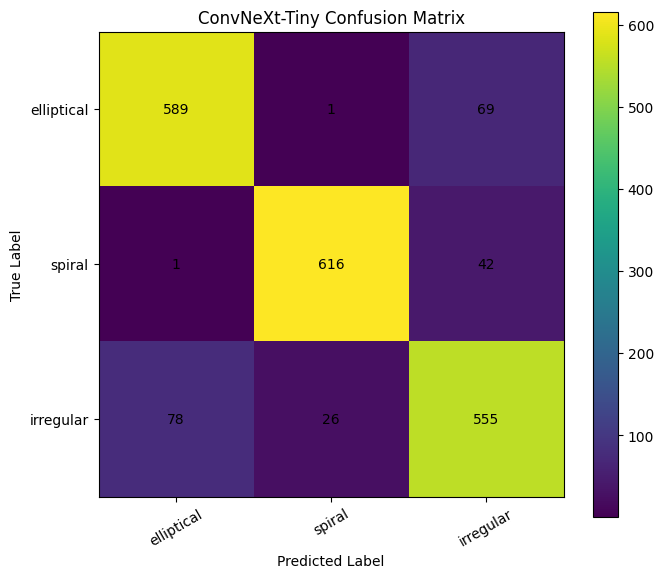

In [32]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes,
    rotation=30
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "ConvNeXt-Tiny Confusion Matrix"
)

for i in range(len(classes)):
    for j in range(len(classes)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

CONFUSION_PATH = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    CONFUSION_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 24. Training History and Learning Curves

Stage 1 and Stage 2 training histories are combined to visualize **accuracy and loss** over the full training process. These curves help assess learning progress, validation performance, and possible overfitting.


In [33]:
train_accuracy = (
    history_stage1.history["accuracy"]
    +
    history_stage2.history["accuracy"]
)

val_accuracy = (
    history_stage1.history["val_accuracy"]
    +
    history_stage2.history["val_accuracy"]
)

train_loss = (
    history_stage1.history["loss"]
    +
    history_stage2.history["loss"]
)

val_loss = (
    history_stage1.history["val_loss"]
    +
    history_stage2.history["val_loss"]
)

epochs = range(
    1,
    len(train_accuracy) + 1
)

fine_tune_start = (
    len(
        history_stage1.history["accuracy"]
    )
)

## 25. Saving Training History and Experiment Summary
Saves the combined training history and key experiment settings so the run can be inspected and compared with other models later.

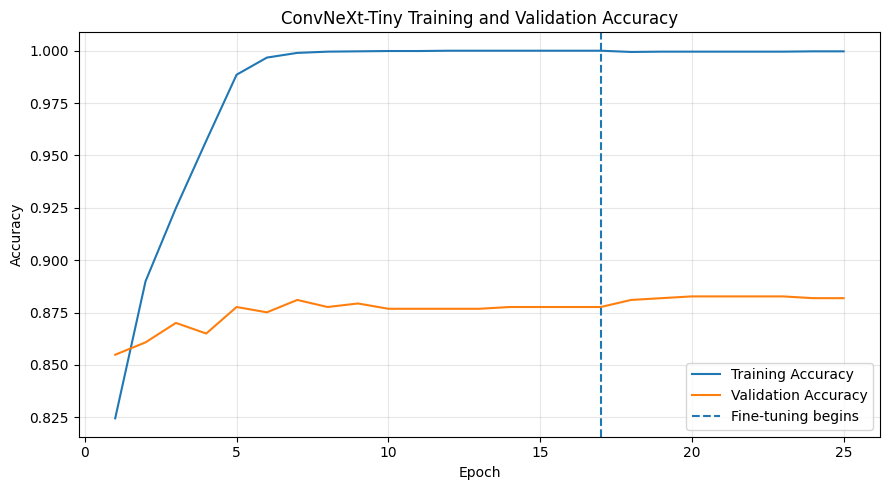

In [34]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    epochs,
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    label="Validation Accuracy"
)

plt.axvline(
    fine_tune_start,
    linestyle="--",
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "ConvNeXt-Tiny Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ACCURACY_GRAPH_PATH = os.path.join(
    RESULTS_DIR,
    "accuracy_curve.png"
)

plt.savefig(
    ACCURACY_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

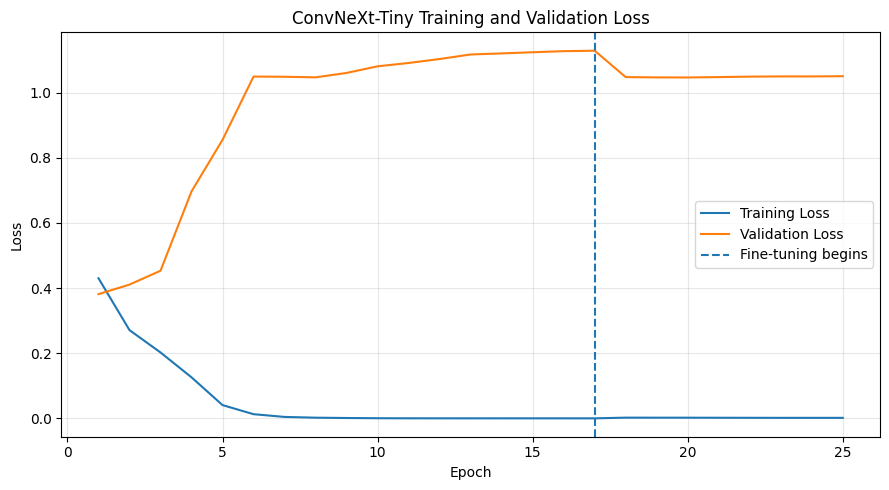

In [35]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    epochs,
    train_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    label="Validation Loss"
)

plt.axvline(
    fine_tune_start,
    linestyle="--",
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ConvNeXt-Tiny Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_GRAPH_PATH = os.path.join(
    RESULTS_DIR,
    "loss_curve.png"
)

plt.savefig(
    LOSS_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
history_df = pd.DataFrame({
    "epoch": list(epochs),
    "train_accuracy": train_accuracy,
    "validation_accuracy": val_accuracy,
    "train_loss": train_loss,
    "validation_loss": val_loss
})

history_path = os.path.join(
    RESULTS_DIR,
    "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(
    "Saved:",
    history_path
)

Saved: /kaggle/working/results/training_history.csv


## 26. Saving and Inspecting Test Predictions
Saves the true class, predicted class, confidence, and correctness for each test image. This also supports later error analysis.

In [ ]:
best_val_accuracy = max(stage1_best_val_acc, stage2_best_val_acc)
combined_val_accuracy = (
    history_stage1.history["val_accuracy"]
    + history_stage2.history["val_accuracy"]
)
best_epoch = int(np.argmax(combined_val_accuracy) + 1)
total_training_minutes = (stage1_time + stage2_time) / 60

summary = {
    "model": "ConvNeXt-Tiny full fine-tune",
    "dataset": "Galaxy Zoo 2",
    "classes": classes,
    "images_per_class": int(N_PER_CLASS),
    "input_size": list(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "threshold": float(THRESHOLD),
    "random_seed": int(SEED),
    "test_accuracy": float(accuracy),
    "test_accuracy_percent": float(accuracy * 100),
    "test_loss": float(test_loss),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "best_validation_accuracy": float(best_val_accuracy),
    "best_epoch": best_epoch,
    "training_time_minutes": float(total_training_minutes),
    "fine_tuned_layers": int(FINE_TUNE_LAYERS),
    "total_parameters": int(best_model.count_params()),
}

SUMMARY_PATH = RESULTS_DIR / "convnext_tiny_summary.json"
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=4)

print(json.dumps(summary, indent=4))

{
    "model": "ConvNeXt-Tiny full fine-tune",
    "dataset": "Galaxy Zoo 2",
    "classes": [
        "elliptical",
        "spiral",
        "irregular"
    ],
    "images_per_class": 3295,
    "input_size": [
        256,
        256
    ],
    "batch_size": 16,
    "threshold": 0.8,
    "random_seed": 42,
    "test_accuracy": 0.8902377339403136,
    "test_accuracy_percent": 89.02377339403135,
    "test_loss": 0.9542742967605591,
    "macro_precision": 0.8910263971797204,
    "macro_recall": 0.8902377339403135,
    "macro_f1": 0.8905630207677989,
    "weighted_f1": 0.890563020767799,
    "best_validation_accuracy": 0.8827004432678223,
    "best_epoch": 20,
    "training_time_minutes": 39.725596757729846,
    "fine_tuned_layers": 134,
    "total_parameters": 27822435
}


In [ ]:
filenames = [os.path.basename(file_path) for file_path in test_file_paths]

prediction_df = pd.DataFrame({
    "filename": filenames,
    "true_class_index": y_true,
    "predicted_class_index": y_pred,
    "true_class": [classes[i] for i in y_true],
    "predicted_class": [classes[i] for i in y_pred],
    "confidence": np.max(prediction_probabilities, axis=1),
})

prediction_df["correct"] = (
    prediction_df["true_class"] == prediction_df["predicted_class"]
)

prediction_path = RESULTS_DIR / "test_predictions.csv"
prediction_df.to_csv(prediction_path, index=False)
display(prediction_df.head())

,filename,true_class_index,predicted_class_index,true_class,predicted_class,confidence,correct
0,1000.jpg,0,0,elliptical,elliptical,0.999999,True
1,100907.jpg,0,0,elliptical,elliptical,0.999997,True
2,101697.jpg,0,0,elliptical,elliptical,0.953732,True
3,10180.jpg,0,0,elliptical,elliptical,0.999374,True
4,101819.jpg,0,0,elliptical,elliptical,0.999980,True
